# Forecasting CNBS
Lindsay Fitzpatrick
ljob@umich.edu
08/19/2024
Updated: 03/17/2025

This script performs the following tasks:

1. Loads the database containing processed CFS forecast data.
2. Passes the forecast data through the trained model(s).
3. Generates an ensemble of CNBS forecasts for each of the Great Lakes.
4. Saves the forecasts to a database and/or CSV file.
5. Creates a figure with time series plots and exports it as a PNG file.

The script requires the following files:
- cfs_forecast_data.db
- x_scaler.joblib
- y_scaler.joblib

And at least one or more of the following trained models:
- GP_trained_model.joblib
- RF_trained_model.joblib
- LR_trained_model.joblib
- NN_trained_model.joblib

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import sqlite3
import calendar
import os
import sys
import joblib

In [3]:
# Add the path to the src directory (two levels up)
sys.path.append(os.path.abspath('../../../'))
from src.data_processing import shift_variables, predict_cnbs, add_df_to_db
from src.hydro_utils import convert_mm_to_cms, load_model
from src.data_loader import load_l2swbm_data, load_glcc_data

# User Input

In [4]:
# Directory where the repository is cloned
local_path = '/Users/ljob/Desktop/'

# Path to data directory
dir = local_path + 'cnbs-predictor/data/'

# Path to input CFS forecast database
cfs_database = local_path + 'Data/cfs_forecast_archive.db'

# Path to save CNBS forecast output to a database
cnbs_database = local_path + 'Data/cnbs_forecast_ver.db'

# Path to saved scalers
x_scaler = 'x_scaler.joblib'
y_scaler = 'y_scaler.joblib'

# Define directory to trained models to use along with their paths
models_info = [{'model': 'GP', 'path': 'GP_trained_model_12.joblib'},
               {'model': 'RF', 'path': 'RF_trained_model_12.joblib'},
               {'model': 'LR', 'path': 'LR_trained_model_12.joblib'},
               {'model': 'NN', 'path': 'NN_trained_model_12.joblib'}]

# Surface area [m2] for each region based on the mask file
lake_areas = {
    'superior': 78288645587.81192,
    'michigan-huron': 123626283030.46616,
    'erie': 18596386416.712486, 
    'ontario': 15569248531.837788
    }
land_areas = {
    'superior': 123736048741.43369,
    'michigan-huron': 236478938454.17358,
    'erie': 81902183517.35063,
    'ontario': 64465190376.66068
    }

# Begin Script

In [5]:
# Create a connection to the SQLite database
conn = sqlite3.connect(cfs_database)

# Define the query to get all the data
query = '''
SELECT * FROM cfs_forecast_data
'''

# Execute the query and fetch the data into a DataFrame
data = pd.read_sql(query, conn)

# Close the connection once done
conn.close()

In [6]:
data['date'] = pd.to_datetime(data['cfs_run'], format='%Y%m%d%H')
print(data)

            cfs_run  year  month            lake surface_type      component  \
0        2011040100  2011      4            erie         lake  precipitation   
1        2011040100  2011      4            erie         land  precipitation   
2        2011040100  2011      4         ontario         lake  precipitation   
3        2011040100  2011      4         ontario         land  precipitation   
4        2011040100  2011      4  michigan-huron         lake  precipitation   
...             ...   ...    ...             ...          ...            ...   
3420760  2021090712  2021     12         ontario         land    evaporation   
3420761  2021090712  2021     12  michigan-huron         lake    evaporation   
3420762  2021090712  2021     12  michigan-huron         land    evaporation   
3420763  2021090712  2021     12        superior         lake    evaporation   
3420764  2021090712  2021     12        superior         land    evaporation   

         value [mm]                date

In [7]:
# Create a datetime column from the 'year' and 'month' columns (set day to 1)
data['forecast_date'] = pd.to_datetime(dict(year=data['year'], month=data['month'], day=1))

# Calculate the lead time in months
data['forecast_month'] = (data['forecast_date'].dt.year - data['date'].dt.year) * 12 + \
                       (data['forecast_date'].dt.month - data['date'].dt.month)

# Drop the intermediate column if you don't need it
data.drop(columns='forecast_date', inplace=True)

In [8]:
# Create column names
data['column_name'] = (
    data['lake'] + '_' +
    data['surface_type'] + '_' +
    data['component'] + '_mo' +
    data['forecast_month'].astype(str)
)

In [9]:
print(data)

            cfs_run  year  month            lake surface_type      component  \
0        2011040100  2011      4            erie         lake  precipitation   
1        2011040100  2011      4            erie         land  precipitation   
2        2011040100  2011      4         ontario         lake  precipitation   
3        2011040100  2011      4         ontario         land  precipitation   
4        2011040100  2011      4  michigan-huron         lake  precipitation   
...             ...   ...    ...             ...          ...            ...   
3420760  2021090712  2021     12         ontario         land    evaporation   
3420761  2021090712  2021     12  michigan-huron         lake    evaporation   
3420762  2021090712  2021     12  michigan-huron         land    evaporation   
3420763  2021090712  2021     12        superior         lake    evaporation   
3420764  2021090712  2021     12        superior         land    evaporation   

         value [mm]                date

In [10]:
# Pivot the DataFrame to wide format
df_wide = data.pivot(index='date', columns='column_name', values='value [mm]')

In [11]:
print(df_wide)

column_name          erie_lake_air_temperature_mo0  \
date                                                 
2011-04-01 00:00:00                     278.204989   
2011-04-01 06:00:00                     278.241128   
2011-04-01 12:00:00                     277.811723   
2011-04-01 18:00:00                     276.300335   
2011-04-02 00:00:00                     279.520935   
...                                            ...   
2021-09-06 12:00:00                     291.337556   
2021-09-06 18:00:00                     290.354873   
2021-09-07 00:00:00                     289.699682   
2021-09-07 06:00:00                     289.374503   
2021-09-07 12:00:00                     289.722884   

column_name          erie_lake_air_temperature_mo1  \
date                                                 
2011-04-01 00:00:00                     281.828651   
2011-04-01 06:00:00                     282.278927   
2011-04-01 12:00:00                     283.234158   
2011-04-01 18:00:00        

In [12]:
# Remove any columns ending in '_month10'
df_wide = df_wide.loc[:, ~df_wide.columns.str.endswith('_mo10')]
df_wide.dropna(inplace=True)
# Remove column level name
df_wide.columns.name = None

# Convert cfs_run to datetime and extract the month
df_wide['date'] = pd.to_datetime(df_wide.index, format='%Y%m%d%H')
df_wide['init_month'] = df_wide['date'].dt.month
df_wide.set_index(pd.to_datetime(df_wide['date']), inplace=True)
df = pd.get_dummies(df_wide, columns=['init_month'], prefix='month')

In [13]:
print(df)

                     erie_lake_air_temperature_mo0  \
date                                                 
2011-04-01 00:00:00                     278.204989   
2011-04-01 06:00:00                     278.241128   
2011-04-01 12:00:00                     277.811723   
2011-04-01 18:00:00                     276.300335   
2011-04-02 00:00:00                     279.520935   
...                                            ...   
2021-09-06 06:00:00                     289.205273   
2021-09-06 12:00:00                     291.337556   
2021-09-06 18:00:00                     290.354873   
2021-09-07 00:00:00                     289.699682   
2021-09-07 06:00:00                     289.374503   

                     erie_lake_air_temperature_mo1  \
date                                                 
2011-04-01 00:00:00                     281.828651   
2011-04-01 06:00:00                     282.278927   
2011-04-01 12:00:00                     283.234158   
2011-04-01 18:00:00        

In [14]:
feature_column_order = (
    [f'month_{i}' for i in range(1, 13)] +
    [
        f'{lake}_{surface_type}_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for surface_type in ['lake', 'land']
        for comp in ['precipitation', 'evaporation', 'air_temperature']
        for m in range(10) #from 0 to 9, representing the 10 months of lead time
    ]
)

target_column_order = [
        f'{lake}_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for comp in ['precipitation', 'evaporation', 'runoff', 'nbs']
        for m in range(12) #from 0 to 11, representing the 12 month forecast
        ]

In [15]:
X_reorg = df[feature_column_order]
print(X_reorg)

                     month_1  month_2  month_3  month_4  month_5  month_6  \
date                                                                        
2011-04-01 00:00:00    False    False    False     True    False    False   
2011-04-01 06:00:00    False    False    False     True    False    False   
2011-04-01 12:00:00    False    False    False     True    False    False   
2011-04-01 18:00:00    False    False    False     True    False    False   
2011-04-02 00:00:00    False    False    False     True    False    False   
...                      ...      ...      ...      ...      ...      ...   
2021-09-06 06:00:00    False    False    False    False    False    False   
2021-09-06 12:00:00    False    False    False    False    False    False   
2021-09-06 18:00:00    False    False    False    False    False    False   
2021-09-07 00:00:00    False    False    False    False    False    False   
2021-09-07 06:00:00    False    False    False    False    False    False   

Run CFS data through the trained models

In [48]:
# Path to GLSEA SST data
sst_path = dir + 'glsea/glsea_sst_1995-2024.csv'

df_sst = pd.read_csv(sst_path, sep=r'\s+', skiprows=6, comment='-')

# Convert Year + Day-of-year to datetime
df_sst['date'] = pd.to_datetime(df_sst['Year'].astype(str) + df_sst['Day'].astype(str), format='%Y%j')

# Set date as index and drop Year/Day columns
df_sst.set_index('date', inplace=True)
df_sst.drop(columns=['Year', 'Day'], inplace=True)

# Rename columns
df_sst.columns = ['superior_sst', 'michigan_sst', 'huron_sst', 'erie_sst', 'ontario_sst', 'stclair_sst']

#Calculate Michigan-Huron average
df_sst['michigan-huron_sst'] = (df_sst['michigan_sst'] + df_sst['huron_sst']) / 2

#Convert SST from Celsius to Kelvin to be consistent with other data
df_sst_k = df_sst + 273.15

df_sst_k = df_sst_k.reindex(columns=['superior_sst', 'michigan-huron_sst', 'erie_sst', 'ontario_sst'])

print(df_sst_k.head())

            superior_sst  michigan-huron_sst  erie_sst  ontario_sst
date                                                               
1995-01-01        276.44             277.910    277.85       277.23
1995-01-02        276.43             277.850    277.79       277.20
1995-01-03        276.42             277.770    277.73       277.17
1995-01-04        276.42             277.700    277.66       277.14
1995-01-05        276.37             277.555    277.43       277.12


In [49]:
X_merged = pd.merge(df_sst_k, X_reorg, left_index=True, right_index=True, how='inner')
print(X_merged)

            superior_sst  michigan-huron_sst  erie_sst  ontario_sst  \
date                                                                  
2011-04-01        273.35             274.445    274.59       275.41   
2011-04-02        273.35             274.490    274.68       275.40   
2011-04-03        273.96             274.725    274.89       275.42   
2011-04-04        274.68             274.905    275.21       275.67   
2011-04-05        274.75             275.010    275.48       275.76   
...                  ...                 ...       ...          ...   
2021-09-03        291.14             295.130    297.60       296.10   
2021-09-04        291.01             294.790    297.35       295.94   
2021-09-05        290.86             294.520    297.04       295.66   
2021-09-06        290.62             294.305    296.82       295.35   
2021-09-07        290.36             294.065    296.70       295.17   

            superior_lake_precipitation_mo0  superior_lake_precipitation_mo1

In [16]:
x_scaler = joblib.load(x_scaler)
y_scaler = joblib.load(y_scaler)

In [17]:
X_scaled = x_scaler.transform(X_reorg)

In [18]:
print(X_scaled)

[[-0.30151134 -0.30151134 -0.30151134 ... -0.5757423  -1.16064969
  -1.14631052]
 [-0.30151134 -0.30151134 -0.30151134 ... -0.60888257 -1.41664931
  -1.61267351]
 [-0.30151134 -0.30151134 -0.30151134 ... -0.61843939 -1.0783898
  -1.76730893]
 ...
 [-0.30151134 -0.30151134 -0.30151134 ... -0.44630468  0.21199562
   0.8010821 ]
 [-0.30151134 -0.30151134 -0.30151134 ... -0.23239746  0.3482873
   0.98564068]
 [-0.30151134 -0.30151134 -0.30151134 ... -0.39276809  0.37362903
   0.66086142]]


In [19]:
gp_model = load_model('GP', models_info)

In [20]:
y_pred_scaled = gp_model.predict(X_scaled)

In [21]:
y_pred = y_scaler.inverse_transform(y_pred_scaled)
df = pd.DataFrame(y_pred, columns=target_column_order, index=X_reorg.index)

In [26]:
print(df)

                     superior_precipitation_mo0  superior_precipitation_mo1  \
date                                                                          
2011-04-01 00:00:00                  104.943304                   31.283301   
2011-04-01 06:00:00                   57.940650                   88.560509   
2011-04-01 12:00:00                   67.285838                   66.441947   
2011-04-01 18:00:00                   58.838677                   72.563057   
2011-04-02 00:00:00                   66.548170                   63.492993   
...                                         ...                         ...   
2021-09-06 06:00:00                  112.021395                   72.548564   
2021-09-06 12:00:00                  112.217526                  100.149490   
2021-09-06 18:00:00                   72.235444                  153.237109   
2021-09-07 00:00:00                   96.644113                   82.770200   
2021-09-07 06:00:00                  118.000883     

In [ ]:
# Reshape the dataframe where each forecast month is a seperate row 

def reshape_forecast_df(df):
    df = df.copy()
    df.index = pd.to_datetime(df.index)

    # Melt the DataFrame into long format
    df_melted = df.reset_index().melt(id_vars='date', var_name='variable', value_name='value')

    # Extract base variable name and month offset
    df_melted['base_variable'] = df_melted['variable'].str.extract(r'^(.*)_mo\d+$')[0]
    df_melted['month_offset'] = df_melted['variable'].str.extract(r'_mo(\d+)$')[0].astype(int)

    # Calculate forecast_month using DateOffset
    df_melted['forecast_month'] = df_melted.apply(
        lambda row: (row['date'] + pd.DateOffset(months=row['month_offset'])).strftime('%Y-%m'),
        axis=1
    )

    # Pivot so each base_variable becomes a column
    df_pivoted = df_melted.pivot_table(
        index=['date', 'month_offset', 'forecast_month'],
        columns='base_variable',
        values='value'
    ).reset_index()

    # Optional: flatten the MultiIndex columns if needed
    df_pivoted.columns.name = None

    return df_pivoted

df_reshaped = reshape_forecast_df(df)

print(df_reshaped)


                      date  month_offset forecast_month  erie_evaporation  \
0      2011-04-01 00:00:00             0        2011-04         32.490261   
1      2011-04-01 00:00:00             1        2011-05         43.455030   
2      2011-04-01 00:00:00             2        2011-06         52.426027   
3      2011-04-01 00:00:00             3        2011-07         80.878091   
4      2011-04-01 00:00:00             4        2011-08        100.916546   
...                    ...           ...            ...               ...   
150259 2021-09-07 06:00:00             7        2022-04         20.376727   
150260 2021-09-07 06:00:00             8        2022-05         32.889918   
150261 2021-09-07 06:00:00             9        2022-06         54.324583   
150262 2021-09-07 06:00:00            10        2022-07         56.951911   
150263 2021-09-07 06:00:00            11        2022-08         99.458044   

          erie_nbs  erie_precipitation  erie_runoff  \
0       290.683278  

In [30]:
# Load GLCC observed data
glcc_dir = dir + 'GLCC/'
df_glcc = load_glcc_data(glcc_dir, 'mm')

In [31]:
l2_dir = dir + 'L2SWBM/'
df_l2 = load_l2swbm_data(l2_dir)

In [33]:
df_reshaped['cfs_run'] = df_reshaped['date']
df_reshaped['date'] = pd.to_datetime(df_reshaped['forecast_month'], format='%Y-%m')

In [36]:
df_obs = pd.merge(df_glcc, df_l2, on=('date'), how='left')
df_obs.dropna(inplace=True)

In [63]:
df_combined = pd.merge(df_reshaped, df_obs, on=('date'), how='left')
df_combined.dropna(inplace=True)

print(df_combined)


             date  month_offset forecast_month  erie_evaporation    erie_nbs  \
0      2011-04-01             0        2011-04         32.490261  290.683278   
1      2011-05-01             1        2011-05         43.455030  206.536685   
2      2011-06-01             2        2011-06         52.426027  190.618309   
3      2011-07-01             3        2011-07         80.878091  115.254613   
4      2011-08-01             4        2011-08        100.916546   -5.497442   
...           ...           ...            ...               ...         ...   
150259 2022-04-01             7        2022-04         20.376727  260.556420   
150260 2022-05-01             8        2022-05         32.889918  158.524232   
150261 2022-06-01             9        2022-06         54.324583  121.131209   
150262 2022-07-01            10        2022-07         56.951911   58.535909   
150263 2022-08-01            11        2022-08         99.458044  -77.400538   

        erie_precipitation  erie_runoff

In [57]:
from properscoring import crps_ensemble
from sklearn.metrics import mean_squared_error, r2_score

def calculate_ensemble_skill(df, var_list, model, date_col='date'):
    df_model = df

    all_obs = []
    all_pred_means = []
    all_pred_ensembles = []

    for var in var_list:
        pred_col = var
        obs_col = f"{var}_obs"

        if pred_col not in df_model.columns or obs_col not in df_model.columns:
            print(f"Warning: Missing columns for '{var}', skipping.")
            continue

        data = df_model[[date_col, pred_col, obs_col]].dropna()
        if data.empty:
            print(f"Warning: No data for '{var}', skipping.")
            continue

        grouped = data.groupby(date_col)

        for date, group in grouped:
            obs = group[obs_col].iloc[0]  # repeated obs per date
            preds = group[pred_col].values

            all_obs.append(obs)
            all_pred_means.append(np.mean(preds))
            all_pred_ensembles.append(preds)

    all_obs = np.array(all_obs)
    all_pred_means = np.array(all_pred_means)

    rmse = np.sqrt(mean_squared_error(all_obs, all_pred_means))
    r2 = r2_score(all_obs, all_pred_means)
    bias = np.mean(all_pred_means - all_obs)
    var_ratio = np.var(all_pred_means) / np.var(all_obs)
    nse = 1 - np.sum((all_pred_means - all_obs) ** 2) / np.sum((all_obs - np.mean(all_obs)) ** 2)
    r = np.corrcoef(all_obs, all_pred_means)[0, 1]
    alpha = np.std(all_pred_means) / np.std(all_obs)
    beta = np.mean(all_pred_means) / np.mean(all_obs)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    crps = np.mean([crps_ensemble(o, p) for o, p in zip(all_obs, all_pred_ensembles)])

    return {
        'Model': model,
        'RMSE': rmse,
        'R2': r2,
        'Bias': bias,
        'VarRatio': var_ratio,
        'NSE': nse,
        'KGE': kge,
        'CRPS': crps
    }

def plot_styled_table(df):
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis('off')  # Hide axes

    table_data = [df.columns.to_list()] + df.round(3).values.tolist()

    table = ax.table(
        cellText=table_data,
        loc='center',
        cellLoc='center',
        edges='closed'
    )

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#d3d3d3')
            cell.get_text().set_fontweight('bold')
        cell.get_text().set_fontsize(12)

    for (row, col), cell in table.get_celld().items():
        cell.set_height(0.17)
        if col == 0:
            cell.set_width(0.2)
        else:
            cell.set_width(0.15)

    table.auto_set_font_size(False)
    plt.show()

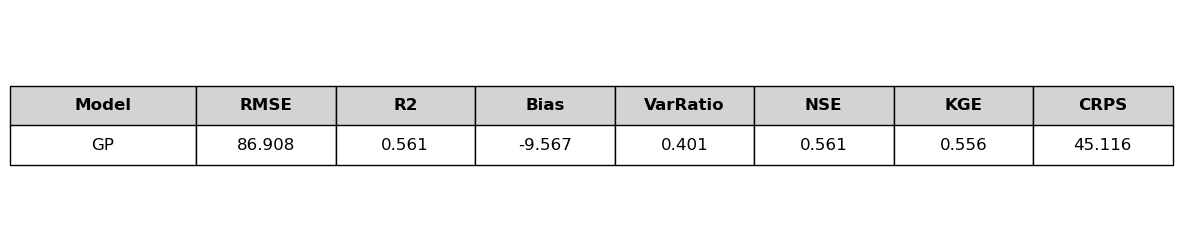

In [47]:
# Calculate skill for just NBS

# variables
components = ['nbs']   # or ['precipitation', 'evaporation', 'runoff']
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
var_list = [f"{lake}_{comp}" for lake in lakes for comp in components]

# Calculate skill for each model
models = ['GP']
results = []

for m in models:
    skill = calculate_ensemble_skill(df_combined, var_list, m, date_col='date')
    results.append(skill)

# Convert to DataFrame for pretty display
results_df = pd.DataFrame(results)

# Plot
plot_styled_table(results_df)

In [64]:
df_combined.rename(columns=lambda col: col.replace('precip_', 'precipitation_').replace('evap_', 'evaporation_'), inplace=True)

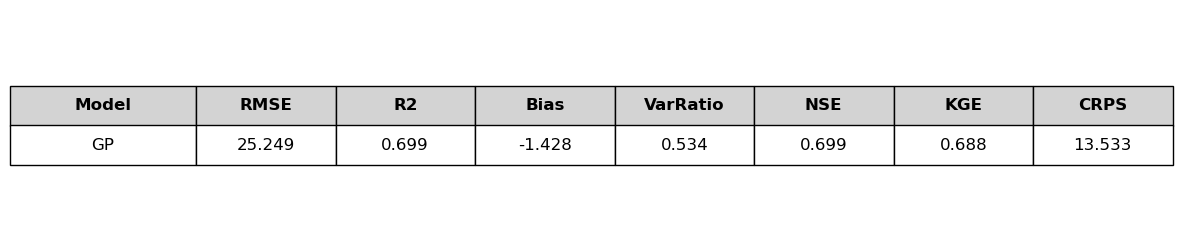

In [66]:
# Calculate skill for component variables: precipitation, evaporation, and runoff

# variables
components = ['precipitation', 'evaporation', 'runoff']
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
var_list = [f"{lake}_{comp}" for lake in lakes for comp in components]

# Calculate skill for each model
models = ['GP']
results = []

for m in models:
    skill = calculate_ensemble_skill(df_combined, var_list, m, date_col='date')
    results.append(skill)

# Convert to DataFrame for pretty display
results_df = pd.DataFrame(results)

# Plot
plot_styled_table(results_df)

In [68]:
df_mean = df_combined.groupby('date').mean(numeric_only=True)

print(df_mean)

            month_offset  erie_evaporation    erie_nbs  erie_precipitation  \
date                                                                         
2011-04-01      0.000000         32.742804  429.526956          160.066968   
2011-05-01      0.500000         48.318600  204.350403          103.650951   
2011-06-01      1.303167         66.218181  119.026246           92.749172   
2011-07-01      1.605678         93.426727   41.368917           92.531775   
2011-08-01      2.004854        120.323230  -11.576687           91.724727   
...                  ...               ...         ...                 ...   
2022-04-01      9.425587         14.436137  216.208960           69.735024   
2022-05-01      9.750000         29.292329  163.271523           77.091858   
2022-06-01      9.981928         31.709131  129.865143           75.676861   
2022-07-01     10.826389         62.229256   28.934520           70.271968   
2022-08-01     11.000000         99.822174  -39.471764          

Plot the forecasts for each component for each lake by model output

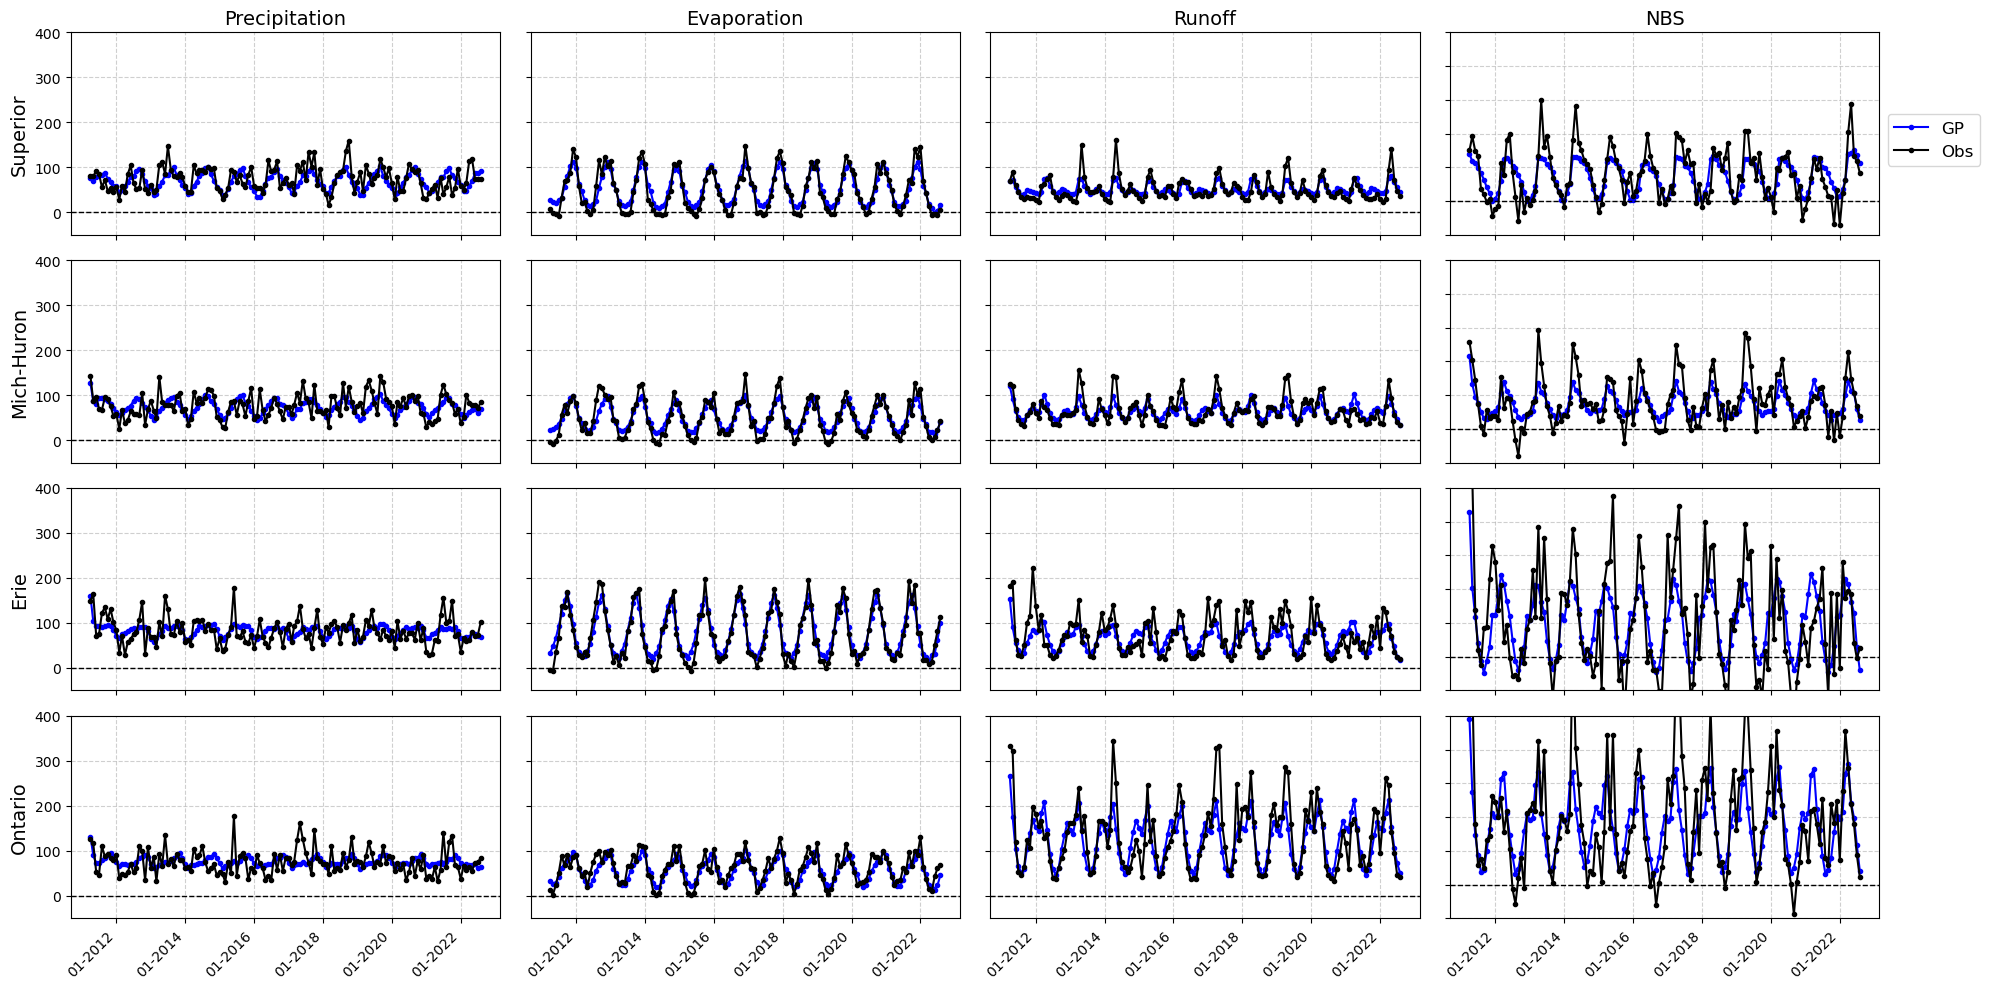

In [70]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Define model colors
#model_colors = {'GP': 'blue', 'RF': 'green', 'LR': 'red', 'NN': 'purple'}

# Define lake names and components
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
components = ['precipitation', 'evaporation', 'runoff', 'nbs']
titles = ['Precipitation', 'Evaporation', 'Runoff', 'NBS']
ylabels = ['Superior', 'Mich-Huron', 'Erie', 'Ontario']

df_mean = df_combined.groupby('date').mean(numeric_only=True)


# Create subplot grid
fig, axs = plt.subplots(4, 4, figsize=(20, 10))
axs = axs.reshape(4, 4)

# Loop through all combinations of lake and component
for row, lake in enumerate(lakes):
    for col, comp in enumerate(components):
        ax = axs[row, col]
        column = f'{lake}_{comp}'
        obs_column = f'{column}_obs'

        # Plot model prediction
        ax.plot(df_mean.index, df_mean[column], marker='o', markersize=3,
                color='blue', label='GP')
        # Plot observations
        ax.plot(df_mean.index, df_mean[obs_column], marker='o', markersize=3,
                color='black', linewidth=1.5, label='Obs')

        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_yticks(np.arange(-1000, 1000, 100))

        # Set titles and labels
        if row == 0:
            ax.set_title(titles[col], fontsize=14)
        if row == 3:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
            ax.tick_params(axis='x', rotation=45)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment('right')
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(ylabels[row], fontsize=14)
        else:
            ax.set_yticklabels([])
        if col == 3:
            ax.set_ylim(-100, 500)
        else:
            ax.set_ylim(-50, 400)

# Add legend once
axs[0, 3].legend(loc='lower left', bbox_to_anchor=(1, 0.3), fontsize=12)

start_date = pd.to_datetime('2011-04-01')
end_date = pd.to_datetime('2022-01-01')

#for ax_row in axs:
#    for ax in ax_row:
#        ax.set_xlim(start_date, end_date)

# Save and show plot
plt.tight_layout()
#plt.savefig('CNBS_forecasts.png', dpi=300)
plt.show()